# Cryptography Lab
**Asymmetric Cryptography — Problem Set 2**

This notebook walks through key generation to cryptanalysis attacks, with interactive experiments.

## 0 — Setup & Core Implementation

All helpers in one cell. Run this first!

In [92]:
import random, time, math
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# ── Primitives ──────────────────────────────────────────────

def is_prime(n, k=10):
    """Miller-Rabin primality test. Error prob ≤ (1/4)^k."""
    if n < 2: return False
    if n < 4: return True
    if n % 2 == 0: return False
    r, d = 0, n - 1
    while d % 2 == 0:
        r += 1; d //= 2
    for _ in range(k):
        a = random.randrange(2, n - 1)
        x = pow(a, d, n)
        if x == 1 or x == n - 1: continue
        for _ in range(r - 1):
            x = pow(x, 2, n)
            if x == n - 1: break
        else:
            return False
    return True

def gen_prime(bits):
    """Generate a random prime of `bits` bit-length."""
    while True:
        n = random.getrandbits(bits) | (1 << (bits - 1)) | 1
        if is_prime(n): return n

def extended_gcd(a, b):
    if a == 0: return b, 0, 1
    g, x1, y1 = extended_gcd(b % a, a)
    return g, y1 - (b // a) * x1, x1

def mod_inverse(e, phi):
    """d such that e·d ≡ 1 (mod phi)"""
    _, x, _ = extended_gcd(e % phi, phi)
    return x % phi

# ── RSA Key Generation ──────────────────────────────────────

def rsa_keygen(bits):
    """
    Returns (public_key, private_key, p, q).
    public_key  = (n, e)
    private_key = (n, d)
    """
    half = max(bits // 2, 4)
    p = gen_prime(half)
    q = gen_prime(half)
    while q == p:
        q = gen_prime(half)
    n = p * q
    phi = (p - 1) * (q - 1)
    e = 65537 if bits >= 32 else 3
    while math.gcd(e, phi) != 1:
        e += 2
    d = mod_inverse(e, phi)
    return (n, e), (n, d), p, q

def rsa_encrypt_text(text, pub):
    n, e = pub
    return [pow(ord(ch), e, n) for ch in text]

def rsa_decrypt_blocks(blocks, priv):
    n, d = priv
    return ''.join(chr(pow(c, d, n)) for c in blocks)

# ── Attack Methods ──────────────────────────────────────────

def attack_trial(n):
    """Trial division: test every i up to √n."""
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return i, n // i
    return None

def attack_fermat(n, max_iter=100_000):
    """Fermat: n = a² − b². Fast when p ≈ q."""
    a = math.isqrt(n) + 1
    for _ in range(max_iter):
        b2 = a * a - n
        b = math.isqrt(b2)
        if b * b == b2:
            return a - b, a + b
        a += 1
    return None

def attack_pollard(n, max_iter=100_000):
    """Pollard's ρ with Floyd's cycle detection."""
    if n % 2 == 0: return 2, n // 2
    for c in range(1, 20):
        f = lambda x: (x * x + c) % n
        x = y = random.randrange(2, n)
        d = 1
        while d == 1:
            x = f(x)
            y = f(f(y))
            d = math.gcd(abs(x - y), n)
        if 1 < d < n:
            return d, n // d
    return None

def attack_qs(n, B_size=60):
    """Simplified Quadratic Sieve (educational)."""
    def small_primes(limit):
        return [p for p in range(2, limit) if is_prime(p)]
    base = small_primes(min(B_size, 200))
    root = math.isqrt(n)
    smooth = []
    for x in range(root + 1, root + 10000):
        y = x * x - n
        if y <= 0: continue
        tmp = y
        for p in base:
            while tmp % p == 0: tmp //= p
        if tmp == 1:
            smooth.append((x, y))
        if len(smooth) > len(base) + 5:
            break
    # try pairwise products
    for i in range(len(smooth)):
        for j in range(i + 1, len(smooth)):
            prod = smooth[i][1] * smooth[j][1]
            s = math.isqrt(prod)
            if s * s == prod:
                xx = (smooth[i][0] * smooth[j][0]) % n
                d = math.gcd(xx - s, n)
                if 1 < d < n:
                    return d, n // d
    return None

ATTACKS = {
    'Trial Division': attack_trial,
    'Fermat':         attack_fermat,
    'Pollard ρ':      attack_pollard,
    'Quadratic Sieve': attack_qs,
}

def crack_rsa(pub, cipher, method_fn):
    """Full attack pipeline: factor n → recover d → decrypt."""
    n, e = pub
    result = method_fn(n)
    if result is None: return None, None
    p, q = result
    d = mod_inverse(e, (p-1)*(q-1))
    return (p, q), ''.join(chr(pow(c, d, n)) for c in cipher)

print('Core loaded — ready to start!')

Core loaded — ready to start!


---
## 1 — RSA Basics: Key Generation & Encrypt/Decrypt

**Math recap:**
1. Pick primes $p, q$. Compute $n = pq$, $\;\varphi(n) = (p-1)(q-1)$.
2. Choose $e$ with $\gcd(e, \varphi) = 1$. Compute $d = e^{-1} \bmod \varphi$.
3. **Encrypt:** $c = m^e \bmod n$ &nbsp;|&nbsp; **Decrypt:** $m = c^d \bmod n$

Works because $m^{ed} \equiv m \pmod{n}$ (Euler's theorem).

In [99]:
#@title Generate keys & send a message {run: "auto"}
KEY_SIZE = 78  #@param {type:"slider", min:8, max:2048, step:2}
MESSAGE  = "Quantam Teacher teaching Discrete Maths!"  #@param {type:"string"}

pub, priv, p, q = rsa_keygen(KEY_SIZE)
n, e = pub
_, d = priv

print(f'p = {p},  q = {q}')
print(f'n = {n}  ({n.bit_length()} bits)')
print(f'e = {e},  d = {d}')
print()

cipher = rsa_encrypt_text(MESSAGE, pub)
plain  = rsa_decrypt_blocks(cipher, priv)

print(f'Plaintext : {MESSAGE}')
print(f'Cipher    : {cipher[:5]}…')
print(f'Decrypted : {plain}')
print('✓ Match!' if plain == MESSAGE else '✗ MISMATCH')

p = 337219277701,  q = 506247242987
n = 170716329618198777732887  (78 bits)
e = 65537,  d = 128902720159830745614473

Plaintext : Quantam Teacher teaching Discrete Maths!
Cipher    : [165003200444691908102429, 169508240218871898752372, 34079860067354237522032, 55237819769126307032199, 70055908816271314928948]…
Decrypted : Quantam Teacher teaching Discrete Maths!
✓ Match!


---
## 2 — Attack: Trial Division

Test every $i$ from $2$ to $\sqrt{n}$. Complexity $O(\sqrt{n})$ — guaranteed but slow for large $n$.

In [95]:
#@title Trial Division {run: "auto"}
# Uses keys & cipher from Section 1
t0 = time.perf_counter()
factors, cracked = crack_rsa(pub, cipher, attack_trial)
dt = time.perf_counter() - t0

print(f'n = {pub[0]}  (true factors {p}, {q})')
if factors:
    print(f'Found factors: {factors}  in {dt:.6f}s')
    print(f'Decrypted: "{cracked}"')
else:
    print('Failed.')

n = 143  (true factors 11, 13)
Found factors: (11, 13)  in 0.000171s
Decrypted: "Quantam Teacher teaching Discrete Maths!"


---
## 3 — Attack: Fermat's Factorization

Express $n = a^2 - b^2 = (a-b)(a+b)$. Runs in $O(|p-q|)$ — blazing fast when $p \approx q$.

In [96]:
#@title Fermat {run: "auto"}
# Uses keys & cipher from Section 1
t0 = time.perf_counter()
factors, cracked = crack_rsa(pub, cipher, attack_fermat)
dt = time.perf_counter() - t0

print(f'n = {pub[0]}  |p−q| = {abs(p-q)}')
if factors:
    print(f'Found factors: {factors}  in {dt:.6f}s')
    print(f'Decrypted: "{cracked}"')
else:
    print('Failed (primes too far apart for iteration limit).')

n = 143  |p−q| = 2
Found factors: (11, 13)  in 0.000130s
Decrypted: "Quantam Teacher teaching Discrete Maths!"


---
## 4 — Attack: Pollard's ρ

Pseudo-random walk with $f(x) = x^2 + c \bmod n$. Birthday paradox gives expected $O(n^{1/4})$.

In [97]:
#@title Pollard's ρ {run: "auto"}
# Uses keys & cipher from Section 1
t0 = time.perf_counter()
factors, cracked = crack_rsa(pub, cipher, attack_pollard)
dt = time.perf_counter() - t0

print(f'n = {pub[0]}')
if factors:
    print(f'Found factors: {factors}  in {dt:.6f}s')
    print(f'Decrypted: "{cracked}"')
else:
    print('Failed (probabilistic — try re-running).')

n = 143
Found factors: (11, 13)  in 0.000153s
Decrypted: "Quantam Teacher teaching Discrete Maths!"


---
## 5 — Attack: Quadratic Sieve (simplified)

Find $x^2 \equiv y^2 \pmod{n}$, then $\gcd(x-y, n)$ gives a factor.  
Sub-exponential: $O(e^{\sqrt{\ln n \cdot \ln\ln n}})$. Success rate drops on small keys.

In [100]:
#@title Quadratic Sieve {run: "auto"}
# Uses keys & cipher from Section 1
t0 = time.perf_counter()
factors, cracked = crack_rsa(pub, cipher, attack_qs)
dt = time.perf_counter() - t0

print(f'n = {pub[0]}')
if factors:
    print(f'Found factors: {factors}  in {dt:.6f}s')
    print(f'Decrypted: "{cracked}"')
else:
    print('Failed (simplified QS — expected for small keys).')

n = 170716329618198777732887
Failed (simplified QS — expected for small keys).


---
## 6 — Benchmark: All Attacks vs Key Size

Runs each attack across multiple key sizes and plots the results.

10-bit ... done
14-bit ... done
18-bit ... done
22-bit ... done
26-bit ... done
30-bit ... done
42-bit ... done


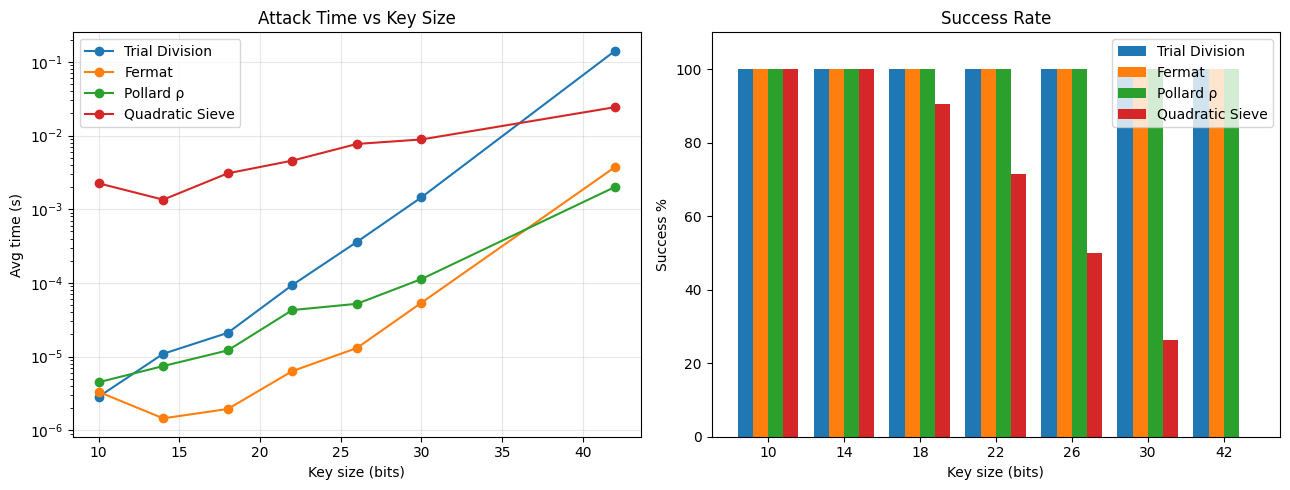

In [101]:
#@title Run Benchmark {run: "auto"}
TRIALS = 42  #@param {type:"slider", min:1, max:2048, step:1}
KEY_SIZES = [10, 14, 18, 22, 26, 30, 42]

results = {name: [] for name in ATTACKS}
success = {name: [] for name in ATTACKS}

for bits in KEY_SIZES:
    print(f'{bits}-bit ...', end=' ', flush=True)
    for name, fn in ATTACKS.items():
        times, wins = [], 0
        for _ in range(TRIALS):
            pub, *_ = rsa_keygen(bits)
            t0 = time.perf_counter()
            r = fn(pub[0])
            times.append(time.perf_counter() - t0)
            if r: wins += 1
        results[name].append(np.mean(times))
        success[name].append(wins / TRIALS * 100)
    print('done')

# ── Plot: Time ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, times in results.items():
    ax1.plot(KEY_SIZES, times, 'o-', label=name)
ax1.set(xlabel='Key size (bits)', ylabel='Avg time (s)', title='Attack Time vs Key Size')
ax1.set_yscale('log')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Plot: Success Rate ──
x = np.arange(len(KEY_SIZES))
w = 0.2
for i, (name, rates) in enumerate(success.items()):
    ax2.bar(x + i*w, rates, w, label=name)
ax2.set(xlabel='Key size (bits)', ylabel='Success %', title='Success Rate', xticks=x + 1.5*w)
ax2.set_xticklabels(KEY_SIZES)
ax2.legend(); ax2.set_ylim(0, 110)

plt.tight_layout(); plt.show()

---
## 7 — All Attacks: Sensitivity to |p − q| Alice → Bob, Eve Attacks

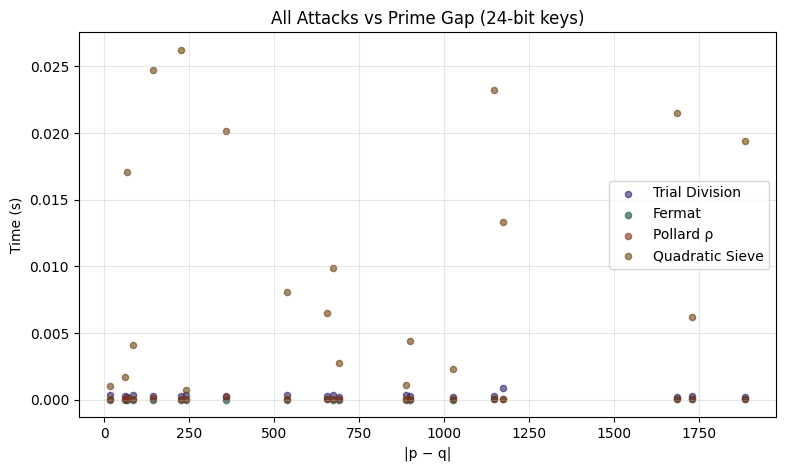

In [54]:
SAMPLES = 30  #@param {type:"slider", min:20, max:200, step:10}

gaps = []
times = {name: [] for name in ATTACKS}

for _ in range(SAMPLES):
    pub, _, p, q = rsa_keygen(24)
    n = pub[0]
    gaps.append(abs(p - q))
    for name, fn in ATTACKS.items():
        t0 = time.perf_counter()
        fn(n)
        times[name].append(time.perf_counter() - t0)

colors = {'Trial Division': '#2B2366', 'Fermat': '#0A4F3A', 'Pollard ρ': '#8A3015', 'Quadratic Sieve': '#6E430C'}
plt.figure(figsize=(9, 5))
for name, t in times.items():
    plt.scatter(gaps, t, s=20, label=name, alpha=0.6, color=colors[name])
plt.xlabel('|p − q|'); plt.ylabel('Time (s)')
plt.title('All Attacks vs Prime Gap (24-bit keys)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

---
## 8 — Theoretical Complexity Comparison

How long each method might take on a real hardware

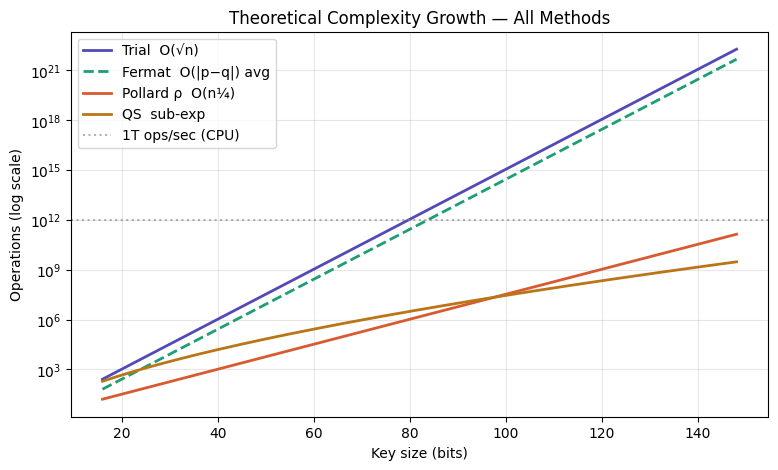

In [102]:
MAX_BITS = 148  #@param {type:"slider", min:16, max:2048, step:4}

bits = np.arange(16, MAX_BITS + 1)
n_vals = 2.0 ** bits

trial_ops   = np.sqrt(n_vals)
pollard_ops = n_vals ** 0.25
qs_ops      = np.exp(np.sqrt(np.log(n_vals) * np.log(np.log(n_vals + 1) + 1)))
# Fermat worst-case is O(√n), best-case O(1); show average ≈ O(√n / 4)
fermat_ops  = np.sqrt(n_vals) / 4

plt.figure(figsize=(9, 5))
plt.semilogy(bits, trial_ops,   label='Trial  O(√n)',         color='#534AB7', linewidth=2)
plt.semilogy(bits, fermat_ops,  label='Fermat  O(|p−q|) avg', color='#1D9E75', linewidth=2, linestyle='--')
plt.semilogy(bits, pollard_ops, label='Pollard ρ  O(n¼)',     color='#D85A30', linewidth=2)
plt.semilogy(bits, qs_ops,      label='QS  sub-exp',          color='#BA7517', linewidth=2)
plt.axhline(y=1e12, color='gray', linestyle=':', alpha=0.6, label='1T ops/sec (CPU)')
plt.xlabel('Key size (bits)'); plt.ylabel('Operations (log scale)')
plt.title('Theoretical Complexity Growth — All Methods')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

---
## 9 — Why Real RSA Is Safe

Extrapolate our timings to see why 2048-bit keys are infeasible to break.

In [103]:
import math as _m

KEY_BITS = 1024  #@param {type:"slider", min:32, max:4096, step:32}

log10_ops = 12
log10_yr  = _m.log10(3.15e7)
log10_2   = _m.log10(2)

def fmt(log_yr):
    if log_yr < -7:  return "< 1 µs"
    if log_yr < 0:   return "< 1 second"
    if log_yr < 1:   return f"~{10**log_yr:.0f} seconds"
    if log_yr < 2:   return f"~{10**log_yr/60:.0f} minutes"
    if log_yr < 5:   return f"~10^{log_yr:.1f} seconds"
    yr = log_yr - log10_yr
    if yr < 0:       return "< 1 year"
    if yr < 1:       return f"~{10**yr:.0f} years"
    if yr < 10.1:    return f"~10^{yr:.1f} years"
    return f"10^{yr:.0f} years  ← way beyond age of universe (10^10 yr)"

log10_n = KEY_BITS * log10_2
ln_n    = KEY_BITS * _m.log(2)

methods = [
    ("Trial division  O(√n)",       log10_n / 2),
    ("Fermat worst    O(√n)",       log10_n / 2),
    ("Pollard ρ       O(n¼)",       log10_n / 4),
    ("Quadratic Sieve  sub-exp",    _m.sqrt(ln_n * _m.log(ln_n)) / _m.log(10)),
]

print(f"Key size: {KEY_BITS} bits  →  n ≈ 10^{log10_n:.0f}\n")
print(f"{'Method':<30} {'Operations':>14}   {'Time @ 10¹² ops/s'}")
print('─' * 72)
for name, log_ops in methods:
    log_sec = log_ops - log10_ops
    log_yr  = log_sec - log10_yr
    print(f"{name:<30} 10^{log_ops:>8.1f}   {fmt(log_yr)}")

print(f"\n{'VERDICT':>30}: ", end="")
best_log = min(m[1] for m in methods)
best_yr  = best_log - log10_ops - log10_yr
if best_yr < 0:      print("  BROKEN — cracked in under a second")
elif best_yr < 2:     print("  WEAK — crackable in hours/days")
elif best_yr < 10.1:  print("  RISKY — feasible with enough resources")
else:                 print(" SECURE — infeasible for any classical computer")

Key size: 1024 bits  →  n ≈ 10^308

Method                             Operations   Time @ 10¹² ops/s
────────────────────────────────────────────────────────────────────────
Trial division  O(√n)          10^   154.1   10^127 years  ← way beyond age of universe (10^10 yr)
Fermat worst    O(√n)          10^   154.1   10^127 years  ← way beyond age of universe (10^10 yr)
Pollard ρ       O(n¼)          10^    77.1   10^50 years  ← way beyond age of universe (10^10 yr)
Quadratic Sieve  sub-exp       10^    29.6   ~10^2.6 years

                       VERDICT:  SECURE — infeasible for any classical computer
